# Decoder scaling — speed and accuracy of the five QEC-head decoders vs system size

Doubled semion (DS), honeycomb OBC patches, QEC sign head `s(σ) = #loops(ε·σ) mod 2` with five
recovery rules `ε` (`model/decoders.py`): **anchor**, **union-find**, **greedy**, **MWPM** (production),
**tie-sum**. Two questions, two figures:

1. **Speed** — head wall-time per configuration and per VMC step vs qubit count N
   (`scripts/bench_decoders.py` microbenchmarks, several machines/code states; in-vivo `t_head`
   from production runs overlaid when present).
2. **Accuracy** — (a) exact ceilings `1 − F_s` (|ψ|²-weighted wrong-sign weight, full 2^N grading,
   `scripts/sign_fidelity.py --decoders`) vs N at fixed field; (b) achieved relative energy error of the
   trained NQS (Combo CNN + head, `cnnqB` arm, minSR lr 0.01, 350 steps, seed 0, 8192 samples) vs N at
   (h_x, h_z) = (0.4, 0); (c) V-score vs N as the optimization-budget signal.

Conventions: N = 3F + 2(Lx+Ly) − 1 qubits; `E_tail` = mean of the last 20 training energies;
rel-err = (E_tail − E_ref)/|E_ref| with `E_ref` the exact E0 where ED exists (N ≤ 27, from the
`signfid_*` gradings) and the **best variational arm** otherwise (every arm is a legitimate upper
bound; hollow markers). Head time per VMC step = µs/config × 8192 × (2 + N + F): the framed
Hamiltonian evaluates the head on the 8192 samples and on all their 1 + N + F connected configurations.

All inputs are read by glob, so cells degrade gracefully while cluster jobs are still landing —
re-execute after each `cluster.sh fetch`. Figures go to `figures/decoder_scaling/` (gitignored).

In [1]:
import os, sys, glob, re, json, pathlib
import numpy as np
import matplotlib.pyplot as plt

# house plot style (shared with the toric-code-nqs repo)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3})

ROOT = pathlib.Path.cwd().resolve()
while not (ROOT / 'results' / 'nqs').is_dir():
    if ROOT.parent == ROOT:
        raise RuntimeError('run this notebook from inside the 2D-TC repo')
    ROOT = ROOT.parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
FIGDIR = ROOT / 'figures' / 'decoder_scaling'; FIGDIR.mkdir(parents=True, exist_ok=True)

from model.honeycomb_geometry import HoneycombGeometry   # numpy-only

DEC = ['anchor', 'unionfind', 'greedy', 'mwpm', 'tie_sum']
DEC_LABEL = {'anchor': 'anchor', 'unionfind': 'union-find', 'greedy': 'greedy',
             'mwpm': 'MWPM (production)', 'tie_sum': 'tie-sum'}
DEC_COLOR = {'anchor': '#D55E00', 'unionfind': '#E69F00', 'greedy': '#009E73',
             'mwpm': '#0072B2', 'tie_sum': '#CC79A7'}                 # Okabe-Ito
DEC_MARK = {'anchor': 's', 'unionfind': 'D', 'greedy': '^', 'mwpm': 'o', 'tie_sum': 'v'}

_geo = {}
def geo(size):
    '''LxxLy -> (N, F, V) via the production geometry (cached).'''
    if size not in _geo:
        Lx, Ly = map(int, size.split('x')); g = HoneycombGeometry(Lx, Ly)
        _geo[size] = (g.N, g.n_plaqs, g.n_vertices)
    return _geo[size]

def steps_per_config_factor(size):
    N, F, V = geo(size); return 8192 * (2 + N + F)

## Data loaders

In [2]:
def load_ceilings():
    '''(hx, hz) -> decoder -> {size: 1 - F_s}. All `_dl` gradings at hy = 0.'''
    files = [f for f in glob.glob('results/diagnostics/signfid_hc*_ds_*_dl*.json') if '_hy' not in f]
    out = {}
    for f in files:
        d = json.load(open(f)); size = f"{d['Lx']}x{d['Ly']}"
        for p in d['points']:
            pt = (round(p['hx'], 3), round(p['hz'], 3))
            for dec, v in p['decoders'].items():
                out.setdefault(pt, {}).setdefault(dec, {})[size] = max(1.0 - v['F_s'], 0.0)
    return out

def load_e0(hx=0.4, hz=0.0):
    '''size -> exact E0 at (hx, hz) from the signfid gradings (k=1 Lanczos, ~1e-9) and results/ed.'''
    e0 = {}
    for f in glob.glob('results/diagnostics/signfid_hc*_ds*.json'):
        if '_hy' in f: continue
        d = json.load(open(f)); size = f"{d['Lx']}x{d['Ly']}"
        for p in d['points']:
            if abs(p['hx'] - hx) < 1e-9 and abs(p['hz'] - hz) < 1e-9:
                e0.setdefault(size, p['E0'])
    for f in glob.glob(f'results/ed/ed_hc*_ds_hx{hx:.2f}_hz{hz:.2f}*.json'):
        m = re.search(r'ed_hc(\d+x\d+)_', f); d = json.load(open(f))
        if m and 'E0' in d: e0.setdefault(m.group(1), d['E0'])
    return e0

def _f(x):
    return complex(str(x)).real if isinstance(x, str) else float(x)

def load_runs(hx=0.4, hz=0.0, arm='cnnqB', tail=20):
    '''(size, decoder) -> dict(E_tail, E_std, V, steps, complete, t_head, step_time, N).'''
    pat = re.compile(rf'G-equiv_1_hc(\d+x\d+)_ds_hx{hx:g}_hz{hz:g}_{arm}(?:_(\w+))?\.json$')
    runs = {}
    for f in sorted(glob.glob(f'results/nqs/G-equiv_1_hc*_ds_hx{hx:g}_hz{hz:g}_{arm}*.json')):
        m = pat.search(os.path.basename(f))
        if not m: continue
        size, dec = m.group(1), m.group(2) or 'mwpm'
        if dec not in DEC: continue
        d = json.load(open(f))
        E = np.array([_f(x) for x in d['energy']], float)
        if E.size == 0: continue
        V = np.array([_f(x) for x in d.get('Vscore', [])], float)
        th = np.array([_f(x) for x in d.get('t_head', [])], float)
        st = np.array([_f(x) for x in (d.get('step_wall') or d.get('step_time') or [])], float)
        runs[(size, dec)] = dict(
            E_tail=E[-tail:].mean(), E_std=E[-tail:].std(), steps=len(E),
            V=float(np.nanmedian(V[-tail:])) if V.size else np.nan,
            complete=os.path.exists(f.replace('.json', '.mpack')),
            t_head=float(np.median(th[-50:])) if th.size and np.nanmax(th) > 0 else np.nan,
            step_time=float(np.median(st[-50:])) if st.size else np.nan,
            N=geo(size)[0], energy=E)
    return runs

def load_bench():
    '''tag -> decoder -> workload -> density -> sorted [(N, us/config, s/step, truncated)].'''
    out = {}
    for f in sorted(glob.glob('results/diagnostics/bench_decoders_*.json')):
        d = json.load(open(f)); tag = d['meta']['tag']
        for r in d['results']:
            if not r.get('us_per_config_median'): continue
            key = round(float(r.get('density') or 0), 4)
            out.setdefault(tag, {}).setdefault(r['decoder'], {}).setdefault(r['workload'], {}) \
               .setdefault(key, []).append((r['N'], r['us_per_config_median'], r['s_per_step_equiv'], bool(r.get('truncated'))))
        out[tag]['_meta'] = {k: d['meta'].get(k) for k in ('cpu', 'git_hash', 'timestamp', 'threads_env')}
    for tag in out:
        for dec in out[tag]:
            if dec.startswith('_'): continue
            for wl in out[tag][dec]:
                for k in out[tag][dec][wl]: out[tag][dec][wl][k].sort()
    return out

def load_disagree():
    '''size -> decoder -> dict(D=sampled disagreement vs mwpm, se, D_exact=2^N |psi|^2-weighted (N<=24 only)).'''
    out = {}
    for f in glob.glob('results/diagnostics/disagree_*.json'):
        d = json.load(open(f)); g = d['geometry']; size = f"{g['Lx']}x{g['Ly']}"
        vs = d.get('disagreement', {}).get('vs_ref', {})
        ex = (d.get('exact') or {}).get('vs_ref_nqs_weighted', {})
        for dec, v in vs.items():
            out.setdefault(size, {})[dec] = dict(D=v['D'], se=max(v.get('se_chain', 0), v.get('se_binomial', 0)),
                                                 upper=v.get('rule_of_three_upper', np.nan), D_exact=ex.get(dec, np.nan))
    return out

CEIL = load_ceilings(); E0 = load_e0(); RUNS = load_runs(); BENCH = load_bench(); DIS = load_disagree()
print('ceiling field points:', sorted(CEIL)); print('sizes with exact E0 at (0.4,0):', sorted(E0, key=lambda s: geo(s)[0]))
print('runs:', len(RUNS), 'sizes', sorted({s for s, _ in RUNS}, key=lambda s: geo(s)[0]))
print('bench tags:', [t for t in BENCH]); print('disagreement files:', sorted(DIS))

ceiling field points: [(0.0, 0.0), (0.0, 0.4), (0.0, 0.8), (0.4, 0.0), (0.4, 0.4), (0.4, 0.8), (0.8, 0.0), (0.8, 0.4), (0.8, 0.8)]
sizes with exact E0 at (0.4,0): ['1x1', '1x2', '1x3', '2x2', '1x4', '1x5', '2x3']
runs: 40 sizes ['1x2', '1x3', '2x2', '1x4', '1x5', '2x3', '3x3', '4x4']
bench tags: ['laptop_asshipped', 'laptop_optimized', 'perlmutter', 'perlmutter_tiesum']
disagreement files: ['1x2', '1x3', '1x4', '1x5', '2x2', '2x3', '3x3']


## Figure 1 — speed: head wall time vs N (five decoders)

Solid = Perlmutter (production hardware, compiled kernels; `bench_decoders_perlmutter*.json`);
dashed = laptop, compiled kernels; dotted = laptop, as-shipped Python decoders (the state before this
session). Production-shaped workload: base configurations with 2% link flips **plus all their 1+N+F
connected configurations**, single thread, warm-up excluded, medians. Right panel converts to seconds per
VMC step; large hollow markers are in-vivo `t_head` medians from production runs (when logged), grey
crosses the total measured step time (GPU + head, `step_wall`, logged by runs after commit 2026-09-02) of the MWPM arm — the head/GPU ratio is the
"is it a bottleneck" answer.

laptop_asshipped       cpu=Apple M1                                 git=d1f56f70 2026-09-01T20:38:47+00:00
laptop_optimized       cpu=Apple M1                                 git=414e9060 2026-09-02T09:15:44+00:00
perlmutter             cpu=AMD EPYC 7763 64-Core Processor          git=a9d48388 2026-09-02T10:27:02+00:00
perlmutter_tiesum      cpu=AMD EPYC 7763 64-Core Processor          git=b4a7ecd7 2026-09-02T10:12:14+00:00


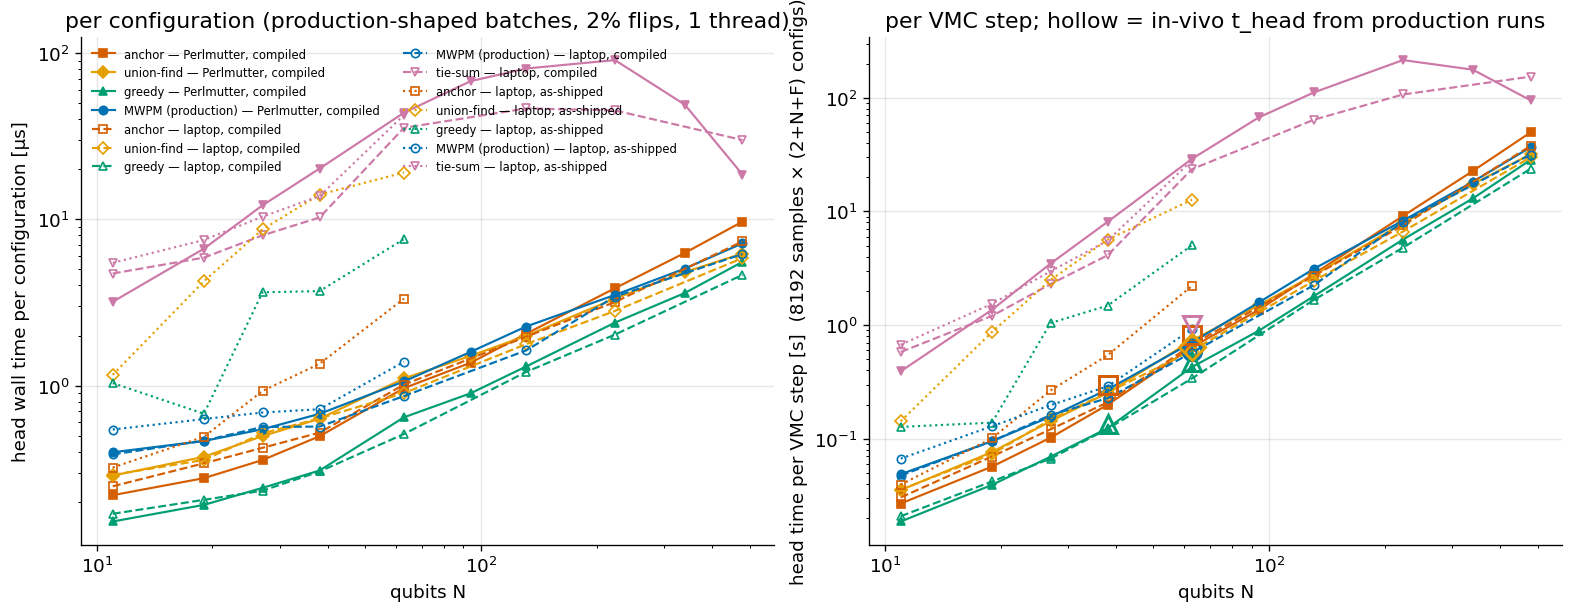

In [3]:
STYLE = [('perlmutter', '-', 'Perlmutter, compiled'), ('perlmutter_tiesum', '-', None),
         ('laptop_optimized', '--', 'laptop, compiled'), ('laptop_asshipped', ':', 'laptop, as-shipped')]
DENS = 0.02
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
shown = set()
for tag, ls, lab in STYLE:
    if tag not in BENCH: continue
    for dec in DEC:
        pts = BENCH[tag].get(dec, {}).get('neighborhood', {}).get(DENS)
        if not pts: continue
        N = [p[0] for p in pts]; us = [p[1] for p in pts]; sps = [p[2] for p in pts]
        label = f"{DEC_LABEL[dec]} — {lab}" if lab and (dec, ls) not in shown else None
        shown.add((dec, ls))
        axes[0].plot(N, us, DEC_MARK[dec] + ls, color=DEC_COLOR[dec], ms=5, lw=1.3, label=label,
                     mfc='none' if ls != '-' else DEC_COLOR[dec])
        axes[1].plot(N, sps, DEC_MARK[dec] + ls, color=DEC_COLOR[dec], ms=5, lw=1.3,
                     mfc='none' if ls != '-' else DEC_COLOR[dec])
        for n, s, tr in zip(N, sps, [p[3] for p in pts]):
            if tr: axes[1].annotate('trunc', (n, s), fontsize=6, xytext=(3, -8), textcoords='offset points', color='gray')
# in-vivo head time per step + total step time (MWPM arm)
for (size, dec), r in RUNS.items():
    if np.isfinite(r['t_head']):
        axes[1].plot(r['N'], r['t_head'], DEC_MARK[dec], color=DEC_COLOR[dec], ms=11, mfc='none', mew=1.8, zorder=5)
mw = sorted([(r['N'], r['step_time']) for (s, d), r in RUNS.items() if d == 'mwpm' and np.isfinite(r['step_time']) and r['step_time'] > 0])
if mw:
    axes[1].plot([p[0] for p in mw], [p[1] for p in mw], 'x', color='0.4', ms=8, mew=1.5, label='total step time, MWPM arm (GPU + head, A100)')
for ax in axes:
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlabel('qubits N')
axes[0].set_ylabel('head wall time per configuration [µs]')
axes[1].set_ylabel('head time per VMC step [s]  (8192 samples × (2+N+F) configs)')
axes[0].set_title('per configuration (production-shaped batches, 2% flips, 1 thread)')
axes[1].set_title('per VMC step; hollow = in-vivo t_head from production runs')
h, l = axes[0].get_legend_handles_labels(); h2, l2 = axes[1].get_legend_handles_labels()
axes[0].legend(h + h2, l + l2, fontsize=7, ncol=2, frameon=False)
fig.savefig(FIGDIR / 'fig1_speed_vs_N.png', dpi=200, bbox_inches='tight')
for tag, m in ((t, BENCH[t]['_meta']) for t in BENCH):
    print(f"{tag:22s} cpu={((m.get('cpu') or {}).get('model_name') or (m.get('cpu') or {}).get('processor'))!s:40.40s} git={str(m.get('git_hash'))[:8]} {m.get('timestamp')}")

## Figure 2 — accuracy vs N

**(a)** exact ceilings `1 − F_s` per decoder at three field points (every size with a full 2^N grading);
**(b)** achieved relative energy error at (0.4, 0): filled = vs exact E0, hollow = vs the best arm at that
size (no ED), × = incomplete run (partial trajectory), dotted = that decoder's exact ceiling at (0.4, 0)
for direct comparison; **(c)** V-score (N·Var/⟨E⟩²) of the same runs — the budget signal.
Sampled disagreement-vs-MWPM proxies (`disagree_*.json`) are overlaid on (a) as small crosses when present.

{'1x2': (-12.32884367, 'ED'), '1x3': (-17.46543148, 'ED'), '2x2': (-20.5227498, 'ED'), '1x4': (-22.60200964, 'ED'), '1x5': (-27.73858959, 'ED'), '2x3': (-28.71896299, 'ED'), '3x3': (np.float64(-39.96076747), 'best')}


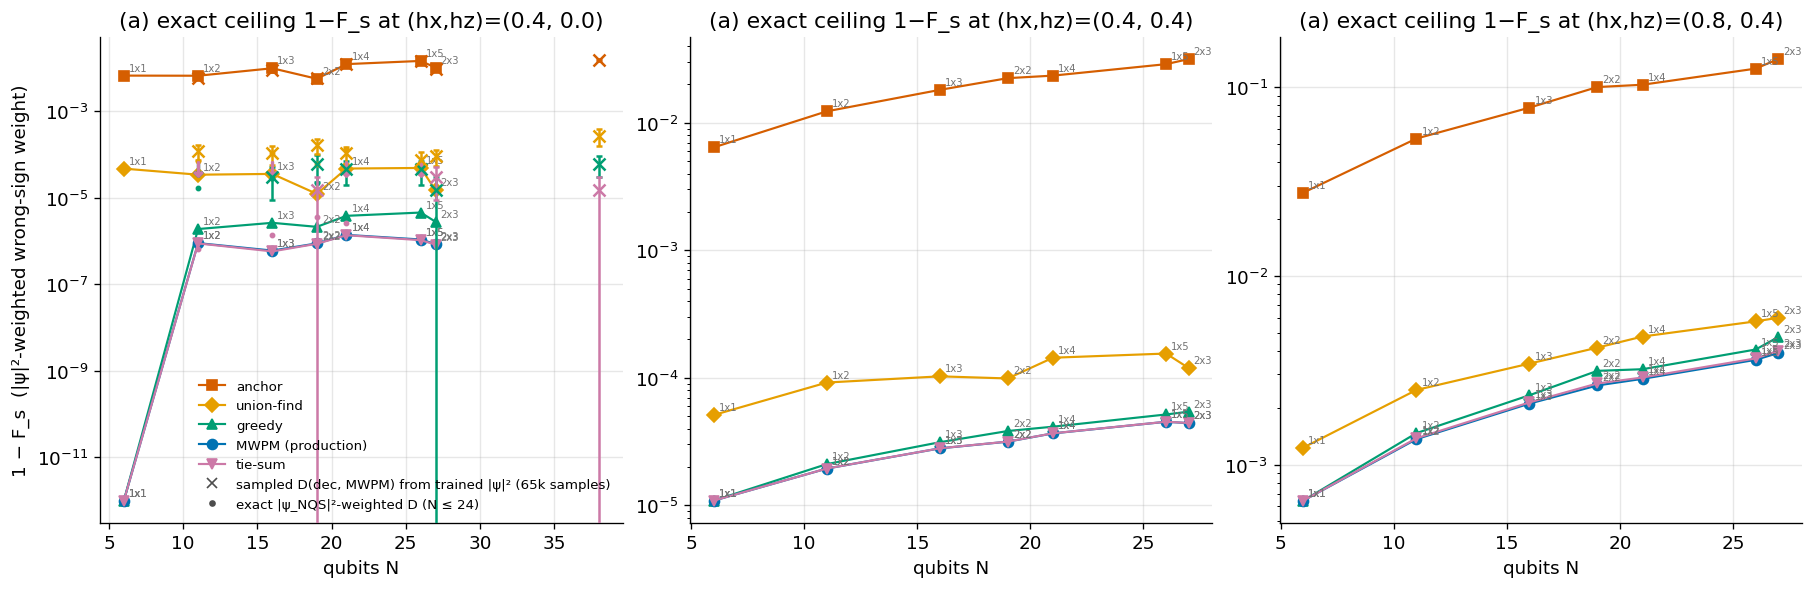

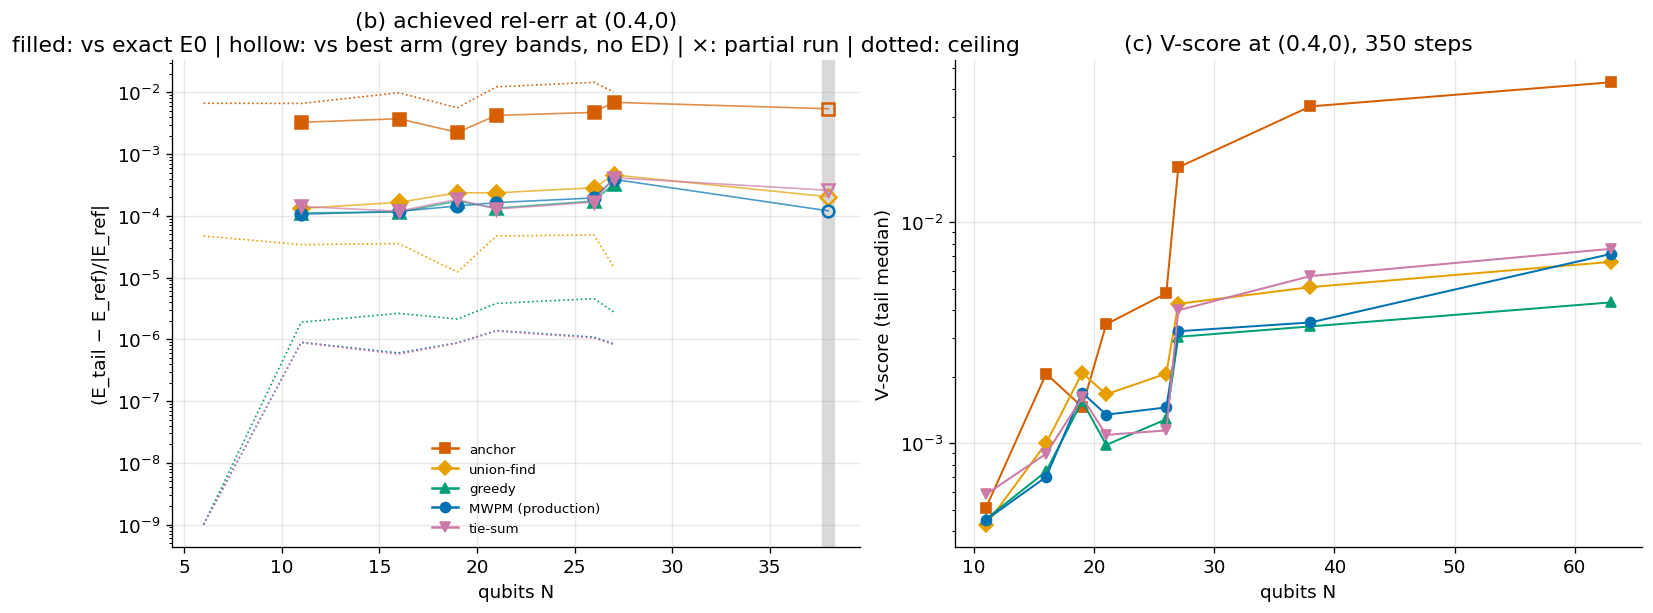

In [4]:
PTS = [(0.4, 0.0), (0.4, 0.4), (0.8, 0.4)]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)
# (a) ceilings
for ax, pt in zip(axes, PTS):
    for dec in DEC:
        sz = CEIL.get(pt, {}).get(dec, {})
        if not sz: continue
        items = sorted(sz.items(), key=lambda kv: geo(kv[0])[0])
        N = [geo(s)[0] for s, _ in items]; y = [max(v, 1e-12) for _, v in items]
        ax.plot(N, y, DEC_MARK[dec] + '-', color=DEC_COLOR[dec], ms=6, lw=1.3, label=DEC_LABEL[dec])
        for (s, v), n in zip(items, N):
            ax.annotate(s, (n, max(v, 1e-12)), fontsize=6, xytext=(3, 3), textcoords='offset points', color='0.45')
    if pt == (0.4, 0.0):
        for size, dd in DIS.items():
            for dec, v in dd.items():
                if dec not in DEC or dec == 'mwpm': continue
                n = geo(size)[0]
                if v['D'] > 0:
                    ax.errorbar(n, v['D'], yerr=v['se'], fmt='x', color=DEC_COLOR[dec], ms=7, mew=1.5, capsize=2, zorder=4)
                else:   # zero sampled disagreements: rule-of-three upper bound as a down-arrow
                    ax.plot(n, v['upper'], marker=r'$\downarrow$', color=DEC_COLOR[dec], ms=9, ls='none', zorder=4)
                if np.isfinite(v.get('D_exact', np.nan)) and v['D_exact'] > 0:
                    ax.plot(n, v['D_exact'], '.', color=DEC_COLOR[dec], ms=5, zorder=4)
        ax.plot([], [], 'x', color='0.3', label='sampled D(dec, MWPM) from trained |ψ|² (65k samples)')
        ax.plot([], [], '.', color='0.3', label='exact |ψ_NQS|²-weighted D (N ≤ 24)')
    ax.set_yscale('log'); ax.set_xlabel('qubits N'); ax.set_title(f'(a) exact ceiling 1−F_s at (hx,hz)={pt}')
axes[0].set_ylabel('1 − F_s  (|ψ|²-weighted wrong-sign weight)'); axes[0].legend(fontsize=8, frameon=False)
fig.savefig(FIGDIR / 'fig2a_ceilings_vs_N.png', dpi=200, bbox_inches='tight')
# (b) achieved rel-err at (0.4,0)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
ax = axes[0]
sizes = sorted({s for s, _ in RUNS}, key=lambda s: geo(s)[0])
ref = {}
for s in sizes:
    if s in E0: ref[s] = (E0[s], 'ED')
    else:
        done = [r['E_tail'] for (ss, d), r in RUNS.items() if ss == s and r['complete']]
        if done: ref[s] = (min(done), 'best')
for dec in DEC:
    xs, ys, kinds = [], [], []
    for s in sizes:
        r = RUNS.get((s, dec));
        if r is None or s not in ref: continue
        e0, kind = ref[s]; rel = (r['E_tail'] - e0) / abs(e0)
        if kind == 'best' and rel <= 0: continue          # the reference arm itself
        xs.append(r['N']); ys.append(max(rel, 1e-9)); kinds.append((kind, r['complete']))
    ax.plot(xs, ys, '-', color=DEC_COLOR[dec], lw=1.0, alpha=0.7)
    for x, y, (kind, comp) in zip(xs, ys, kinds):
        ax.plot(x, y, 'x' if not comp else DEC_MARK[dec], color=DEC_COLOR[dec], ms=7 if comp else 8,
                mfc=DEC_COLOR[dec] if kind == 'ED' else 'none', mew=1.5)
    ax.plot([], [], DEC_MARK[dec] + '-', color=DEC_COLOR[dec], label=DEC_LABEL[dec])
    c = CEIL.get((0.4, 0.0), {}).get(dec, {})
    if c:
        items = sorted(c.items(), key=lambda kv: geo(kv[0])[0])
        ax.plot([geo(s)[0] for s, _ in items], [max(v, 1e-9) for _, v in items], ':', color=DEC_COLOR[dec], lw=1.0)
for s in sizes:
    if s in ref and ref[s][1] == 'best':
        ax.axvline(geo(s)[0], color='0.85', lw=8, zorder=0)
ax.set_yscale('log'); ax.set_xlabel('qubits N'); ax.set_ylabel('(E_tail − E_ref)/|E_ref|')
ax.set_title('(b) achieved rel-err at (0.4,0)\nfilled: vs exact E0 | hollow: vs best arm (grey bands, no ED) | ×: partial run | dotted: ceiling')
ax.legend(fontsize=8, frameon=False)
# (c) V-score
ax = axes[1]
for dec in DEC:
    pts = sorted([(r['N'], r['V']) for (s, d), r in RUNS.items() if d == dec and np.isfinite(r['V'])])
    if pts: ax.plot([p[0] for p in pts], [p[1] for p in pts], DEC_MARK[dec] + '-', color=DEC_COLOR[dec], ms=6, lw=1.2, label=DEC_LABEL[dec])
ax.set_yscale('log'); ax.set_xlabel('qubits N'); ax.set_ylabel('V-score (tail median)'); ax.set_title('(c) V-score at (0.4,0), 350 steps')
fig.savefig(FIGDIR / 'fig2b_relerr_vscore_vs_N.png', dpi=200, bbox_inches='tight')
print({s: (round(v, 8), k) for s, (v, k) in ref.items()})

## Ceiling proxy beyond ED — sampled sign-disagreement vs MWPM

`scripts/decoder_disagreement.py` samples σ ~ |ψ|² from the trained MWPM arm and evaluates all five heads on the same
samples. D(dec, MWPM) counts both directions, so for the near-exact decoders it over-estimates 1−F_s (it includes MWPM's
own tie errors and the configurations where the decoder is right and MWPM wrong); for anchor it reproduces the exact
ceiling. Columns: sampled D ± chain SE, the exact |ψ_NQS|²-weighted D (N ≤ 24), the true 1−F_s from the ED grading.

In [5]:
print(f"{'size':5s}{'N':>4s} {'decoder':11s} {'D sampled':>11s} {'± se':>9s} {'D exact(NQS)':>13s} {'true 1-F_s':>11s}")
for size in sorted(DIS, key=lambda s: geo(s)[0]):
    for dec in DEC:
        v = DIS[size].get(dec)
        if v is None or dec == 'mwpm': continue
        c = CEIL.get((0.4, 0.0), {}).get(dec, {}).get(size, np.nan)
        print(f"{size:5s}{geo(size)[0]:4d} {dec:11s} {v['D']:11.2e} {v['se']:9.1e} {v.get('D_exact', np.nan):13.2e} {c:11.2e}")

size    N decoder       D sampled      ± se  D exact(NQS)  true 1-F_s
1x2    11 anchor         6.01e-03   5.6e-04      6.46e-03    6.63e-03
1x2    11 unionfind      1.22e-04   4.8e-05      7.03e-05    3.42e-05
1x2    11 greedy         0.00e+00   0.0e+00      1.66e-05    1.89e-06
1x2    11 tie_sum        0.00e+00   0.0e+00      6.58e-07    8.81e-07
1x3    16 anchor         8.79e-03   6.2e-04      9.63e-03    9.86e-03
1x3    16 unionfind      1.07e-04   5.1e-05      1.08e-04    3.56e-05
1x3    16 greedy         3.05e-05   2.2e-05      2.94e-05    2.64e-06
1x3    16 tie_sum        0.00e+00   0.0e+00      1.35e-06    5.76e-07
2x2    19 anchor         5.92e-03   4.4e-04      5.49e-03    5.64e-03
2x2    19 unionfind      1.68e-04   6.6e-05      6.15e-05    1.23e-05
2x2    19 greedy         6.10e-05   3.7e-05      2.23e-05    2.13e-06
2x2    19 tie_sum        1.53e-05   1.5e-05      3.68e-06    8.65e-07
1x4    21 anchor         1.23e-02   7.0e-04      1.21e-02    1.23e-02
1x4    21 unionfind 

## Numeric table — every run at (0.4, 0)

In [6]:
print(f"{'size':5s}{'N':>4s} {'decoder':11s}{'steps':>6s} {'E_tail':>14s} {'E_std':>8s} {'V-score':>9s} {'rel-err':>10s} {'ref':>5s} {'ceiling':>9s} {'t_head':>7s} {'s/step':>7s} done")
for s in sizes:
    for dec in DEC:
        r = RUNS.get((s, dec))
        if r is None: continue
        e0, kind = ref.get(s, (np.nan, '—')); rel = (r['E_tail'] - e0) / abs(e0) if np.isfinite(e0) else np.nan
        c = CEIL.get((0.4, 0.0), {}).get(dec, {}).get(s, np.nan)
        print(f"{s:5s}{r['N']:4d} {dec:11s}{r['steps']:6d} {r['E_tail']:14.8f} {r['E_std']:8.1e} {r['V']:9.1e} {rel:10.2e} {kind:>5s} {c:9.1e} {r['t_head']:7.2f} {r['step_time']:7.2f} {'Y' if r['complete'] else 'partial'}")
    if s in ref: print(f"      E_ref({s}) = {ref[s][0]:.10f} [{ref[s][1]}]")

size    N decoder     steps         E_tail    E_std   V-score    rel-err   ref   ceiling  t_head  s/step done
1x2    11 anchor        350   -12.28838392  2.8e-03   5.1e-04   3.28e-03    ED   6.6e-03     nan     nan Y
1x2    11 unionfind     350   -12.32721569  1.1e-03   4.3e-04   1.32e-04    ED   3.4e-05     nan     nan Y
1x2    11 greedy        350   -12.32746529  1.9e-03   4.5e-04   1.12e-04    ED   1.9e-06     nan     nan Y
1x2    11 mwpm          350   -12.32753219  1.3e-03   4.5e-04   1.06e-04    ED   9.0e-07     nan     nan Y
1x2    11 tie_sum       350   -12.32709388  1.3e-03   5.9e-04   1.42e-04    ED   8.8e-07     nan     nan Y
      E_ref(1x2) = -12.3288436697 [ED]
1x3    16 anchor        350   -17.39999768  4.7e-03   2.1e-03   3.75e-03    ED   9.9e-03     nan     nan Y
1x3    16 unionfind     350   -17.46254294  1.9e-03   1.0e-03   1.65e-04    ED   3.6e-05     nan     nan Y
1x3    16 greedy        350   -17.46341974  1.5e-03   7.5e-04   1.15e-04    ED   2.6e-06     nan     n

## Learning curves at the largest size with all five arms

Energy vs step (same seed/recipe); the dashed line is the reference energy for that size.

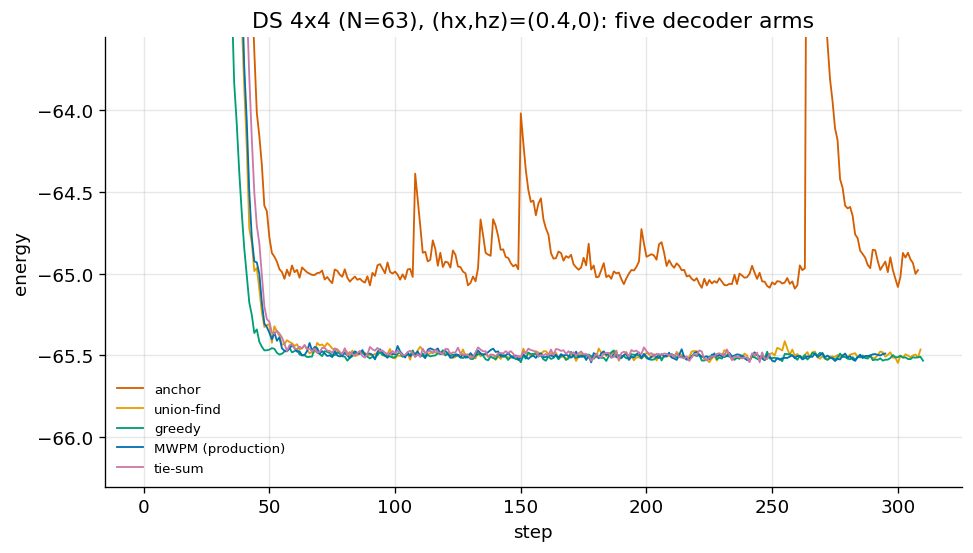

In [7]:
full = [s for s in sizes if all((s, d) in RUNS for d in DEC)]
if full:
    s = full[-1]
    fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
    for dec in DEC:
        E = RUNS[(s, dec)]['energy']; ax.plot(np.arange(len(E)), E, color=DEC_COLOR[dec], lw=1.1, label=DEC_LABEL[dec])
    if s in ref: ax.axhline(ref[s][0], color='0.3', ls='--', lw=1, label=f"E_ref ({ref[s][1]})")
    lo = min(RUNS[(s, d)]['E_tail'] for d in DEC); ax.set_ylim(lo - 0.06 * abs(lo) * 0.2, lo + 0.03 * abs(lo))
    ax.set(xlabel='step', ylabel='energy', title=f'DS {s} (N={geo(s)[0]}), (hx,hz)=(0.4,0): five decoder arms')
    ax.legend(fontsize=8, frameon=False)
    fig.savefig(FIGDIR / f'learning_curves_{s}.png', dpi=200, bbox_inches='tight')
else:
    print('no size has all five arms yet')